Run the following command in the terminal:

sbatch --gpus=1 --gres=gpumem:10g --time=05:00:00 --mem-per-cpu=32g --wrap="jupyter nbconvert --to notebook --execute 02_251218_optimizing_number_of_clusters_Apertus-8B-Instruct.ipynb --inplace"

In [1]:
import os
import json
import pandas as pd

directory_path = "./260603_generated_descriptions_Phi-4-mini-aligned"
data_list = []
# Iterate through all files in the directory
for filename in os.listdir(directory_path):
    if filename.endswith('.json'):
        file_path = os.path.join(directory_path, filename)
        with open(file_path, 'r', encoding='utf-8') as file:
            try:
                data = json.load(file)
                # Ensure it's a dict with 4 key-value pairs
                if isinstance(data, dict):
                    if data["data_point"] == "":
                        print(f"Skipping {filename}, data point empty")
                    
                        continue
                    data_list.append(data)
                else:
                    print(f"Skipping {filename}")
            except json.JSONDecodeError:
                print(f"Skipping {filename}: invalid JSON format.")
                
# Convert list of dicts to DataFrame
df = pd.DataFrame(data_list)
df.tail()

,question,original_source,data_group,data_point,reference_1,reference_2,description,references
2005,What is the meaning of eco-toxicity in relatio...,CPR 2024.pdf,essential environmental characteristics,eco-toxicity,CPR 2024.pdf,BAMB 2019.pdf,Eco-toxicity refers to the harmful effects of ...,[{'text': 'ANNEX II Predetermined environmenta...
2006,What is the meaning of freshwater in relation ...,CPR 2024.pdf,essential environmental characteristics,freshwater,CPR 2024.pdf,ESPR 2024.pdf,Freshwater refers to water bodies such as rive...,[{'text': 'ANNEX II Predetermined environmenta...
2007,What is the meaning of human toxicity cancerog...,CPR 2024.pdf,essential environmental characteristics,human toxicity cancerogenic,CPR 2024.pdf,BAMB 2019.pdf,Human toxicity cancerogenic refers to the pote...,[{'text': 'ANNEX II Predetermined environmenta...
2008,What is the meaning of human toxicity non-canc...,CPR 2024.pdf,essential environmental characteristics,human toxicity non-cancerogenic,CPR 2024.pdf,BAMB 2019.pdf,Human toxicity non-cancerogenic refers to the ...,[{'text': 'ANNEX II Predetermined environmenta...
2009,What is the meaning of land use related impact...,CPR 2024.pdf,essential environmental characteristics,land use related impacts,CPR 2024.pdf,Atta 2021.pdf,Land use related impacts refer to the effects...,[{'text': 'ANNEX II Predetermined environmenta...


In [2]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer
from sentence_transformers import SentenceTransformer


model = SentenceTransformer('./models/BAAI-bge-m3')
description_embeddings = model.encode(df["description"])

In [3]:
import numpy as np
import pandas as pd
import logging
from collections.abc import Iterable
from scipy.sparse import csr_matrix
from scipy.spatial.distance import squareform
from typing import Optional, Union, Tuple


def select_topic_representation(
    ctfidf_embeddings,
    embeddings,
    use_ctfidf: bool = True,
    output_ndarray: bool = False,
):
    """Select the topic representation.

    Arguments:
        ctfidf_embeddings: The c-TF-IDF embedding matrix
        embeddings: The topic embedding matrix
        use_ctfidf: Whether to use the c-TF-IDF representation. If False, topics embedding representation is used, if it
                    exists. Default is True.
        output_ndarray: Whether to convert the selected representation into ndarray
    Raises
        ValueError:
            - If no topic representation was found
            - If c-TF-IDF embeddings are not a numpy array or a scipy.sparse.csr_matrix

    Returns:
        The selected topic representation and a boolean indicating whether it is c-TF-IDF.
    """

    def to_ndarray(array: Union[np.ndarray, csr_matrix]) -> np.ndarray:
        if isinstance(array, csr_matrix):
            return array.toarray()
        return array
    if use_ctfidf:
        if ctfidf_embeddings is None:
            repr_, ctfidf_used = embeddings, False
        else:
            repr_, ctfidf_used = ctfidf_embeddings, True
    else:
        if embeddings is None:
            repr_, ctfidf_used = ctfidf_embeddings, True
        else:
            repr_, ctfidf_used = embeddings, False

    return to_ndarray(repr_) if output_ndarray else repr_, ctfidf_used


def validate_distance_matrix(X, n_samples):
    """Validate the distance matrix and convert it to a condensed distance matrix
    if necessary.

    A valid distance matrix is either a square matrix of shape (n_samples, n_samples)
    with zeros on the diagonal and non-negative values or condensed distance matrix
    of shape (n_samples * (n_samples - 1) / 2,) containing the upper triangular of the
    distance matrix.

    Arguments:
        X: Distance matrix to validate.
        n_samples: Number of samples in the dataset.

    Returns:
        X: Validated distance matrix.

    Raises:
        ValueError: If the distance matrix is not valid.
    """
    # Make sure it is the 1-D condensed distance matrix with zeros on the diagonal
    s = X.shape
    if len(s) == 1:
        # check it has correct size
        n = s[0]
        if n != (n_samples * (n_samples - 1) / 2):
            raise ValueError("The condensed distance matrix must have " "shape (n*(n-1)/2,).")
    elif len(s) == 2:
        # check it has correct size
        if (s[0] != n_samples) or (s[1] != n_samples):
            raise ValueError("The distance matrix must be of shape " "(n, n) where n is the number of samples.")
        # force zero diagonal and convert to condensed
        np.fill_diagonal(X, 0)
        X = squareform(X)
    else:
        raise ValueError(
            "The distance matrix must be either a 1-D condensed "
            "distance matrix of shape (n*(n-1)/2,) or a "
            "2-D square distance matrix of shape (n, n)."
            "where n is the number of documents."
            "Got a distance matrix of shape %s" % str(s)
        )

    # Make sure its entries are non-negative
    if np.any(X < 0):
        raise ValueError("Distance matrix cannot contain negative values.")

    return X

In [4]:
import optuna
import hdbscan
import numpy as np
from umap import UMAP
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.datasets import fetch_20newsgroups
from scipy.cluster import hierarchy as sch
from scipy.cluster.hierarchy import linkage, cophenet
from scipy.spatial.distance import pdist
from hdbscan.validity import validity_index
from sklearn.metrics.pairwise import cosine_similarity

def calculate_ccc(topic_model, docs):
    # Hierarchical topics
    linkage_function = lambda x: sch.linkage(x, "ward", optimal_ordering=True)
    _distance_function = lambda x: 1 - cosine_similarity(x)
    
    hierarchical_topics = topic_model.hierarchical_topics(docs, 
                                                          linkage_function=linkage_function, 
                                                          distance_function=_distance_function, 
                                                          use_ctfidf=True)
    
    # Select topic embeddings
    use_ctfidf = True

    # Calculate distance
    embeddings = select_topic_representation(topic_model.c_tf_idf_, topic_model.topic_embeddings_, use_ctfidf)[0][
        topic_model._outliers :
    ]
    distance_function = lambda x: validate_distance_matrix(_distance_function(x), embeddings.shape[0])
    
    dists = distance_function(embeddings)
    linkage_matrix = linkage_function(dists)

    ccc_score, _ = cophenet(linkage_matrix, dists)

    if np.isnan(ccc_score):
        return 0.0

    return ccc_score


ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

def objective(trial, docs, embeddings):
    # --- Hyperparameters to Optimize ---
    
    # UMAP Parameters
    n_neighbors = trial.suggest_int('n_neighbors', 2, 50)
    n_components = trial.suggest_int('n_components', 2, 15)
    min_dist = trial.suggest_float("min_dist", 0.0, 0.3, step=0.01)
    
    # HDBSCAN Parameters
    min_cluster_size = trial.suggest_int('min_cluster_size', 2, 50)
    min_samples = trial.suggest_int('min_samples', 1, 20)
    cluster_selection_epsilon = trial.suggest_float("cluster_selection_epsilon", 0.0, 0.3, step=0.01)
    
    # --- Model Initialization ---
    
    umap_model = UMAP(
        n_neighbors=n_neighbors,
        n_components=n_components,
        min_dist=min_dist,
        metric='cosine',
        random_state=42,
        n_jobs=1 #important for reproducability
    )

    
    hdbscan_model = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        cluster_selection_epsilon=cluster_selection_epsilon,
        metric="euclidean",  
        cluster_selection_method='eom'
    )
    
    topic_model = BERTopic(
        hdbscan_model=hdbscan_model,
        vectorizer_model=CountVectorizer(stop_words='english'),
        ctfidf_model=ctfidf_model, 
        umap_model=umap_model,
        calculate_probabilities=False
        )

    topic_model.fit(docs, embeddings)

    labels = topic_model.get_document_info(docs).Topic
    mask = labels != -1
    n_clusters = len(np.unique(labels[mask]))
    emb_umap = topic_model.umap_model.embedding_
    
    emb_masked = np.ascontiguousarray(emb_umap[mask], dtype=np.float64)
    labels_masked = np.ascontiguousarray(labels[mask], dtype=np.int32)

    dbcv_score = validity_index(emb_masked, labels_masked, metric='euclidean')
    ccc_score = calculate_ccc(topic_model, docs)

    
    # logging for visibility
    print(f"Trial {trial.number}: DBCV={dbcv_score:.3f}, CCC={ccc_score:.3f}")

    # ---- Outlier ratio (fraction of points labeled -1)
    outlier_ratio =  outlier_ratio = np.mean(labels == -1)

    # Store the custom metrics in Optuna
    trial.set_user_attr("dbcv_score", dbcv_score)
    trial.set_user_attr("ccc_score", ccc_score)
    trial.set_user_attr("outlier_ratio", outlier_ratio)
    trial.set_user_attr("n_clusters", n_clusters)

    # Create directory if it doesn't exist
    os.makedirs("optuna_models/Phi-4-mini-instruct-aligned", exist_ok=True)
    
    # Save model (safely serialization)
    model_name = f"optuna_models/Phi-4-mini-instruct-aligned/260603_trial_{trial.number}_model"
    topic_model.save(model_name, serialization="safetensors", save_ctfidf=True)

    return ccc_score, dbcv_score


In [5]:
# 2. Run Multi-Objective Optimization
# Note: 'directions' list matches the return tuple order (DBCV, CCC)
study = optuna.create_study(directions=['maximize', 'maximize'])

study.optimize(lambda trial: objective(trial, df["description"], description_embeddings), n_trials=300, show_progress_bar=True)


[I 2026-06-03 11:49:39,296] A new study created in memory with name: no-name-cca60c49-9077-4390-ab89-5eacab51a297


  0%|          | 0/300 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 333.74it/s]


Trial 0: DBCV=0.030, CCC=0.728
[I 2026-06-03 11:49:55,292] Trial 0 finished with values: [0.7279994225590634, 0.03010539716947409] and parameters: {'n_neighbors': 2, 'n_components': 9, 'min_dist': 0.17, 'min_cluster_size': 25, 'min_samples': 7, 'cluster_selection_epsilon': 0.24}.



100%|██████████| 73/73 [00:00<00:00, 383.45it/s]


...

Trial 297: DBCV=0.913, CCC=0.000
[I 2026-06-03 12:41:46,208] Trial 297 finished with values: [0.0, 0.9133441046493431] and parameters: {'n_neighbors': 48, 'n_components': 14, 'min_dist': 0.21, 'min_cluster_size': 30, 'min_samples': 8, 'cluster_selection_epsilon': 0.14}.



100%|██████████| 1/1 [00:00<00:00, 305.69it/s]
/cluster/home/svangelova/Pre-demolition audits/env/lib/python3.11/site-packages/scipy/cluster/hierarchy.py:1715: RuntimeWarning:

invalid value encountered in scalar divide



Trial 298: DBCV=0.866, CCC=0.000
[I 2026-06-03 12:41:56,747] Trial 298 finished with values: [0.0, 0.8657169158411417] and parameters: {'n_neighbors': 48, 'n_components': 2, 'min_dist': 0.13, 'min_cluster_size': 4, 'min_samples': 11, 'cluster_selection_epsilon': 0.14}.



100%|██████████| 1/1 [00:00<00:00, 316.22it/s]
/cluster/home/svangelova/Pre-demolition audits/env/lib/python3.11/site-packages/scipy/cluster/hierarchy.py:1715: RuntimeWarning:

invalid value encountered in scalar divide



Trial 299: DBCV=0.936, CCC=0.000
[I 2026-06-03 12:42:08,232] Trial 299 finished with values: [0.0, 0.9355678852576705] and parameters: {'n_neighbors': 47, 'n_components': 10, 'min_dist': 0.1, 'min_cluster_size': 6, 'min_samples': 5, 'cluster_selection_epsilon': 0.24}.


In [6]:
df_descriptions = study.trials_dataframe()
df_descriptions.head()

,number,values_0,values_1,datetime_start,datetime_complete,duration,params_cluster_selection_epsilon,params_min_cluster_size,params_min_dist,params_min_samples,params_n_components,params_n_neighbors,user_attrs_ccc_score,user_attrs_dbcv_score,user_attrs_n_clusters,user_attrs_outlier_ratio,system_attrs_NSGAIISampler:generation,state
0,0,0.727999,0.030105,2026-06-03 11:49:39.307146,2026-06-03 11:49:55.292826,0 days 00:00:15.985680,0.24,25,0.17,7,9,2,0.727999,0.030105,13,0.518408,0,COMPLETE
1,1,0.505055,0.638681,2026-06-03 11:49:55.294863,2026-06-03 11:50:05.651747,0 days 00:00:10.356884,0.06,3,0.11,6,5,17,0.505055,0.638681,74,0.211940,0,COMPLETE
2,2,0.636919,0.468158,2026-06-03 11:50:05.653951,2026-06-03 11:50:16.688374,0 days 00:00:11.034423,0.01,29,0.05,4,7,39,0.636919,0.468158,19,0.161194,0,COMPLETE
3,3,0.474145,0.475294,2026-06-03 11:50:16.689895,2026-06-03 11:50:27.034679,0 days 00:00:10.344784,0.09,17,0.13,3,10,18,0.474145,0.475294,37,0.145771,0,COMPLETE
4,4,0.000000,0.861938,2026-06-03 11:50:27.036176,2026-06-03 11:50:38.369189,0 days 00:00:11.333013,0.25,6,0.29,15,15,18,0.000000,0.861938,2,0.000000,0,COMPLETE


In [7]:
import joblib
# Save to a file
joblib.dump(study, "02_260603_multi_clusterdata_descriptions_Phi-4-mini-instruct-aligned.pkl")

['02_260603_multi_clusterdata_descriptions_Phi-4-mini-instruct-aligned.pkl']

In [8]:
df_descriptions.to_csv("02_260603_multi_clusterdata_descriptions_Phi-4-mini-instruct-aligned.csv", index=False)


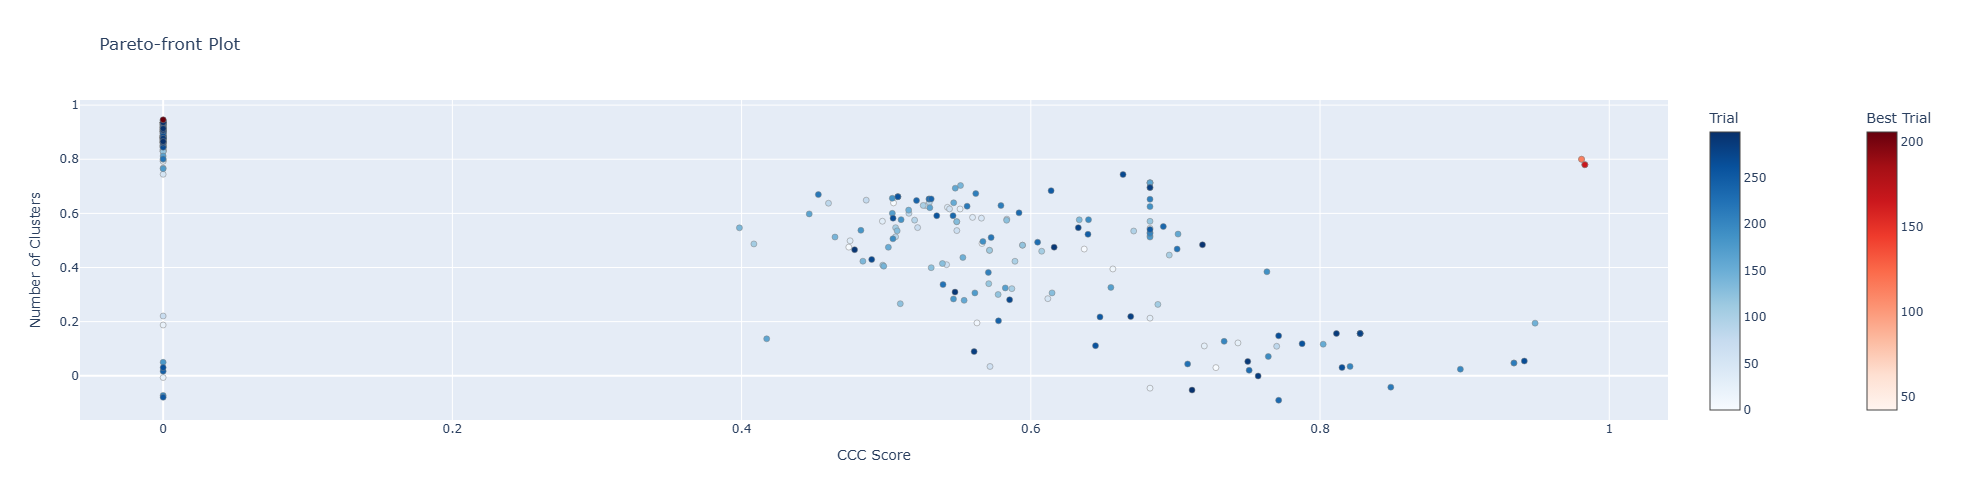

In [9]:
import optuna.visualization as vis

fig = vis.plot_pareto_front(
    study,
    target_names=["CCC Score", "Number of Clusters"], # Names for Obj 0 and Obj 1
    include_dominated_trials=True  # Set to True to see all points, not just the best frontier
)

fig.update_layout(width=600, height=500)
fig.show()